In [1]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import pytorch_lightning as pl
import seaborn as sns
from scipy.signal import find_peaks

from my_funs import *
from sklearn import metrics
from matplotlib import gridspec
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

#import tensorflow as tf 
import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'

dongs = ['강남동', '교  동', '근화동', '남  면', '남산면', '동  면', '동내면', '동산면', 
         '북산면','사북면', '서  면', '석사동', '소양동', '신동면', '신북읍', '신사우동', '약사명동', '조운동','퇴계동', 
         '효자1동', '후평1동']

/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [2]:
def moving_average_alpha(df: pd.DataFrame, unit: float):
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        max_value = dong_df['count'].max()
        back_ewma = dong_df['count'].ewm(alpha = unit).mean()
        back_ewma = back_ewma / back_ewma.max() * (max_value)
        #print(f'{dong} max : {max_value}   ewma_max :{back_ewma.max()}')
        df['count'][dong_df.index] = back_ewma 
    
    #print(max_value , df['count'].max())
    return df


def moving_average_com(df: pd.DataFrame, unit: float):
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        max_value = dong_df['count'].max()
        back_ewma = dong_df['count'].ewm(com = unit).mean()
        back_ewma = back_ewma / back_ewma.max() * (max_value)
        #print(f'{dong} max : {max_value}   ewma_max :{back_ewma.max()}')
        df['count'][dong_df.index] = back_ewma 
    
    #print(max_value , df['count'].max())
    return df

def moving_average_span(df: pd.DataFrame, unit: float):
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        max_value = dong_df['count'].max()
        back_ewma = dong_df['count'].ewm(span = unit).mean()
        back_ewma = back_ewma / back_ewma.max() * (max_value)
        #print(f'{dong} max : {max_value}   ewma_max :{back_ewma.max()}')
        df['count'][dong_df.index] = back_ewma 
    
    #print(max_value , df['count'].max())
    return df
    
def moving_average_halflife(df: pd.DataFrame, unit: float):
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        max_value = dong_df['count'].max()
        back_ewma = dong_df['count'].ewm(halflife = unit).mean()
        back_ewma = back_ewma / back_ewma.max() * (max_value)
        #print(f'{dong} max : {max_value}   ewma_max :{back_ewma.max()}')
        df['count'][dong_df.index] = back_ewma 

    #print(max_value , df['count'].max())
    return df

def moving_average_alpha_both(df: pd.DataFrame, unit: float):
    ret_df = pd.DataFrame()
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        max_value = dong_df['count'].max()
        back_ewma = dong_df['count'].ewm(alpha = unit).mean()

        inv_dong_df = dong_df[::-1]
        for_ewma = inv_dong_df['count'].ewm(alpha = unit).mean()
        
        ewma = (for_ewma + back_ewma) / 2
        ewma = ewma / ewma.max() * max_value
        df['count'][dong_df.index] = ewma 
    
    #print(max_value , df['count'].max())
    return df



In [3]:
def target_plot_pred(data ,dong , title  ):
    fig = plt.figure(figsize=(25, 7))
    
    org_data = data_processing('../../test.csv',0 , None)
    org_data = org_data[org_data['h_dong'] == dong]
    df = data[data['h_dong']==dong]
    
    df_index = df[df['time_idx'] > 24* 7 -1]['REG_DTIME']
    org_count = df[df['time_idx'] > 24* 7 -1 ]['count']
    org_data = org_data[org_data['time_idx'] > 24*7-1]['count']
    
    plt.plot(df_index , org_data, label = '원본' , alpha = 0.3)
    plt.plot(df_index,org_count , label = 'ewma 적용' , alpha=1)
    plt.title(title)
    plt.legend()
    
def target_plot(data ,dong , title  ):
    fig = plt.figure(figsize=(25, 7))
    
    org_data = data_processing('../../test.csv',0 , None)
    org_data = org_data[org_data['h_dong'] == dong]
    df = data[data['h_dong']==dong]
    
    df_index = df['REG_DTIME']
    org_count = df['count']
    org_data = org_data['count']
    
    plt.plot(df_index , org_data, label = '원본' , alpha = 0.3)
    plt.plot(df_index,org_count , label = 'ewma 적용' , alpha=1)
    plt.title(title)
    plt.legend()

In [4]:
def moving_average_alpha(df: pd.DataFrame, unit: float):
    ret_df = pd.DataFrame()
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        max_value = dong_df['count'].max()
        back_ewma = dong_df['count'].ewm(alpha = unit).mean()
        back_ewma = back_ewma / back_ewma.max() * (max_value)
        #print(f'{dong} max : {max_value}   ewma_max :{back_ewma.max()}')
        df['count'][dong_df.index] = back_ewma 
    return df

In [5]:
train_data = data_processing('../../train.csv' , 0.2 , moving_average_alpha)
test_data = data_processing('../../test.csv' , 0, moving_average_alpha)

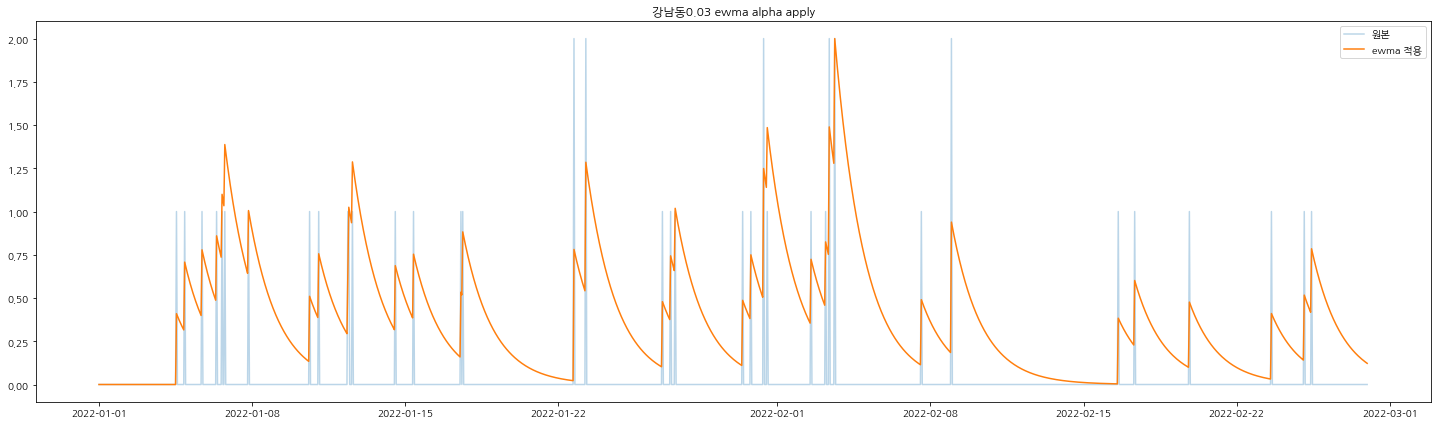

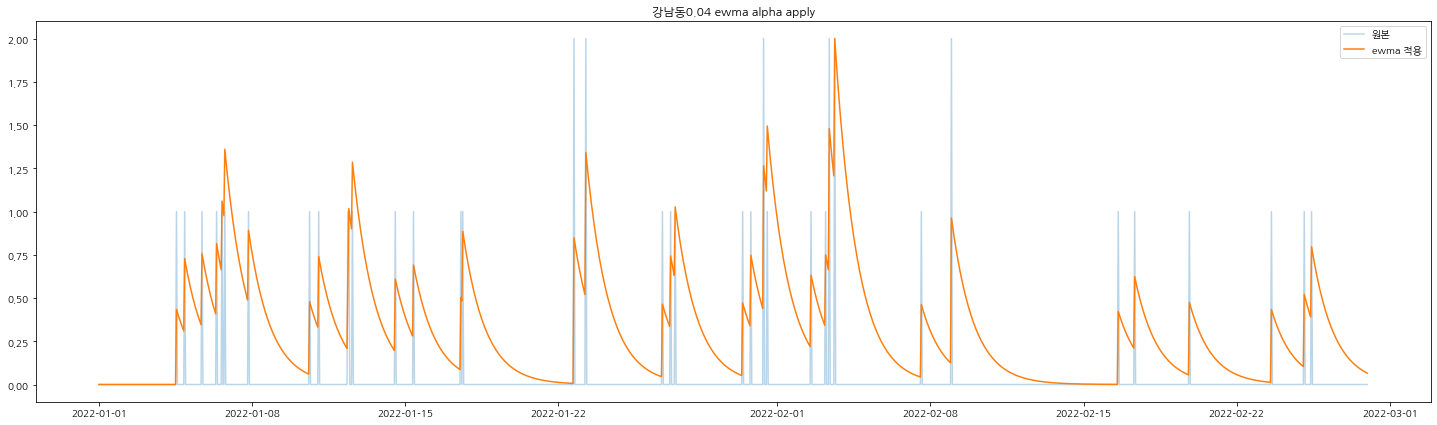

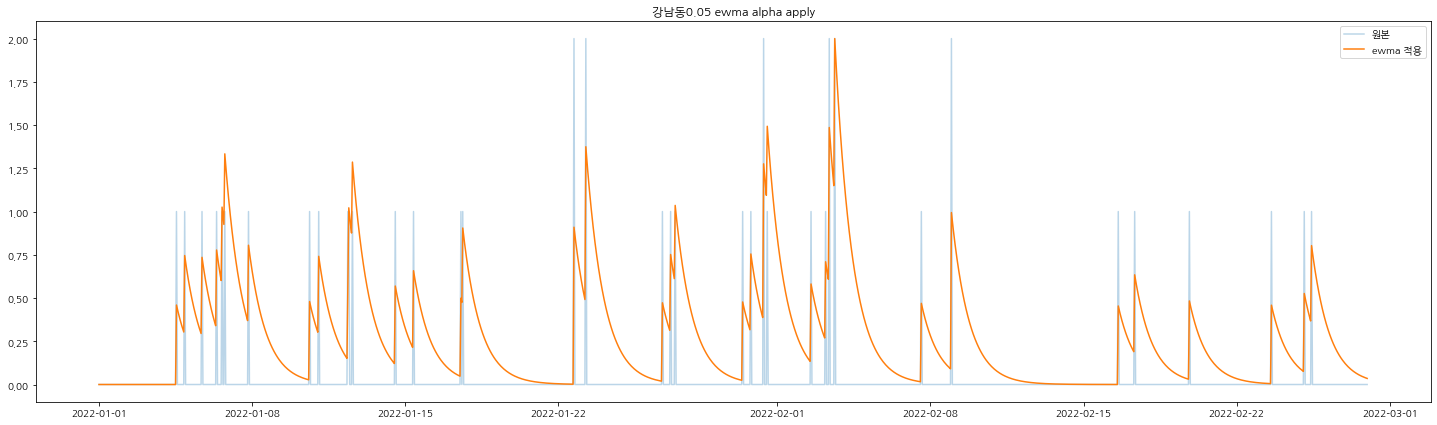

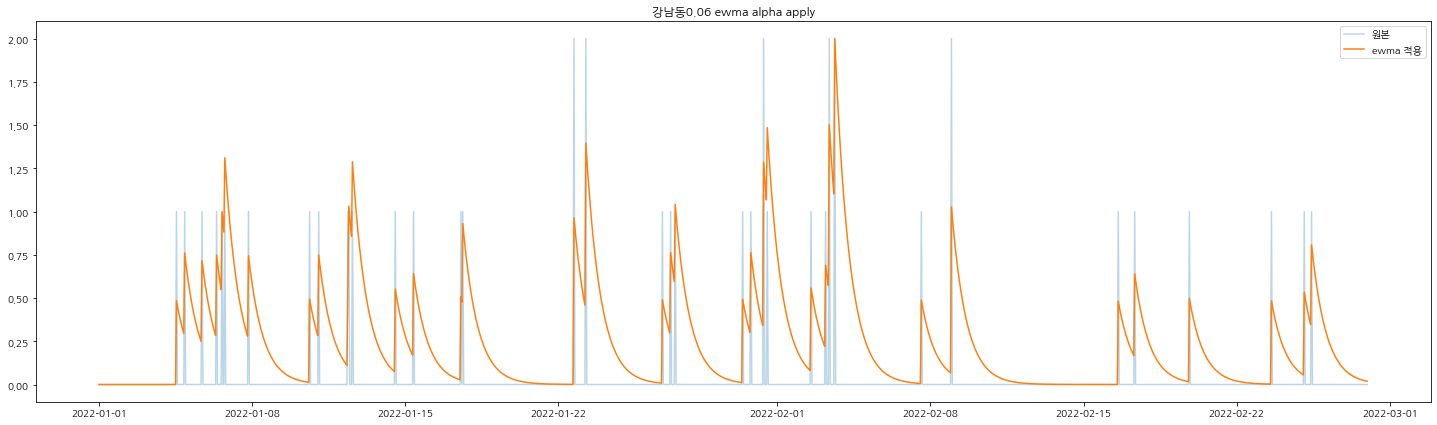

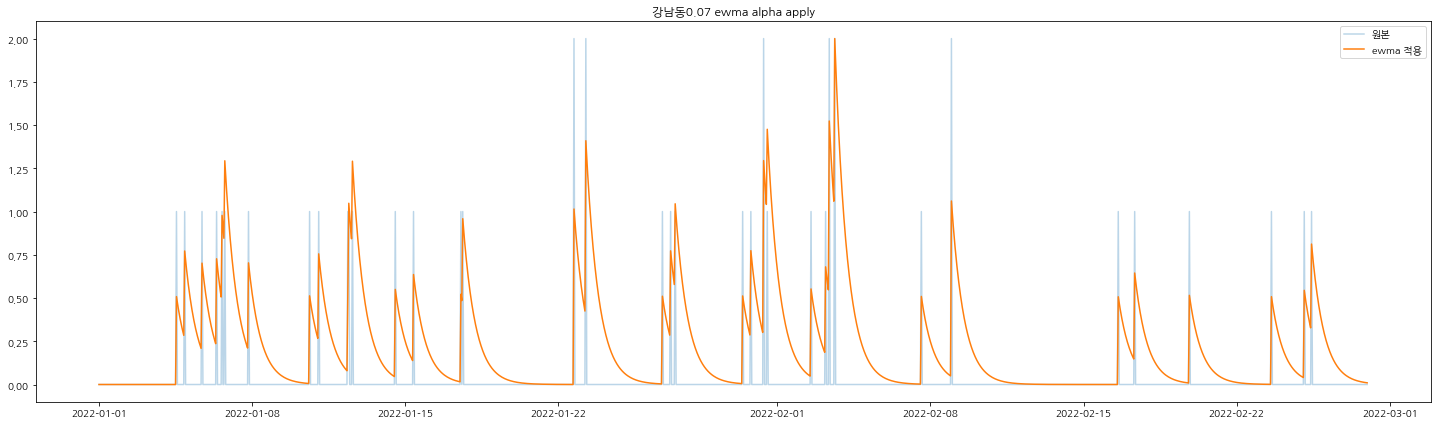

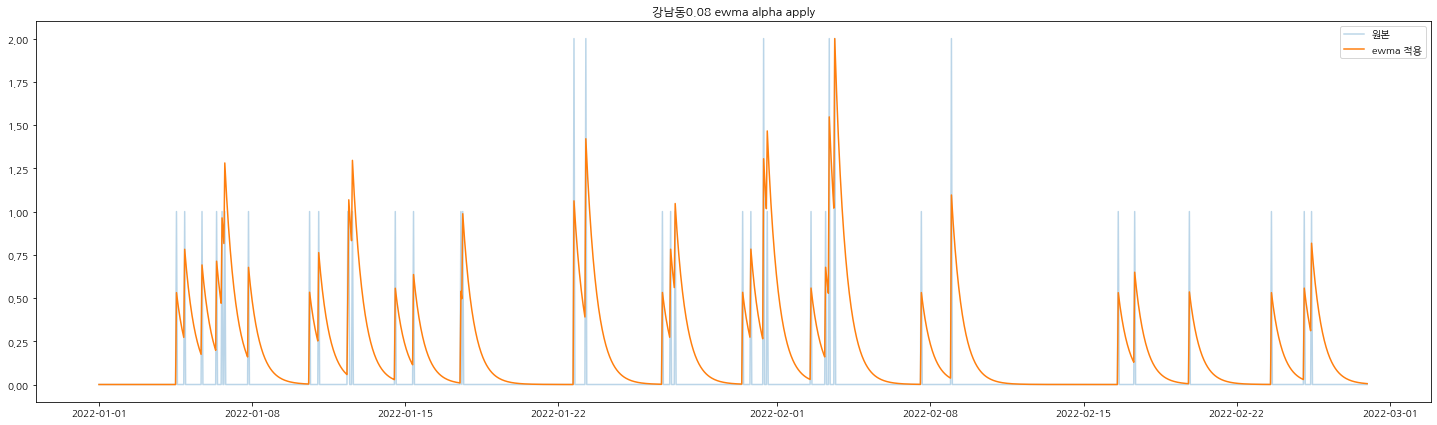

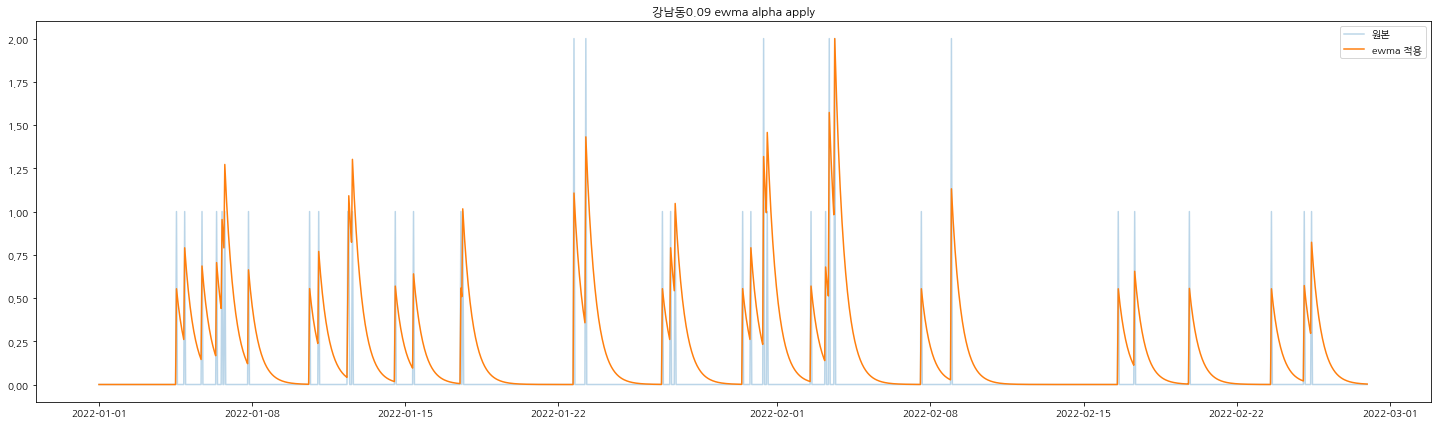

In [6]:
for unit in np.arange(3,10) / 100:
    test_data = data_processing('../../test.csv' , unit, moving_average_alpha)
    target_plot(test_data ,'강남동' , f'강남동{unit} ewma alpha apply')

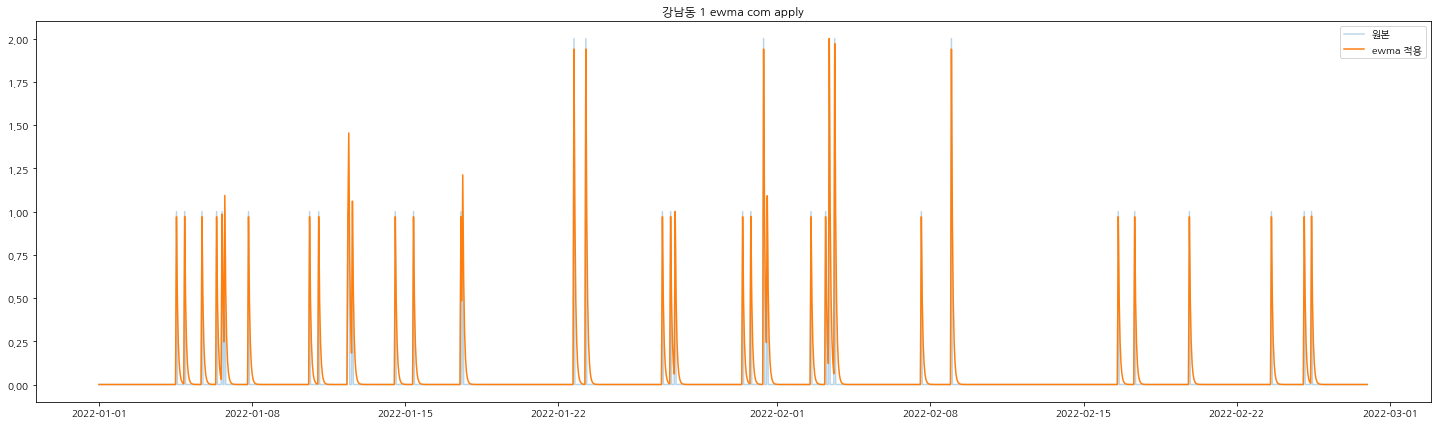

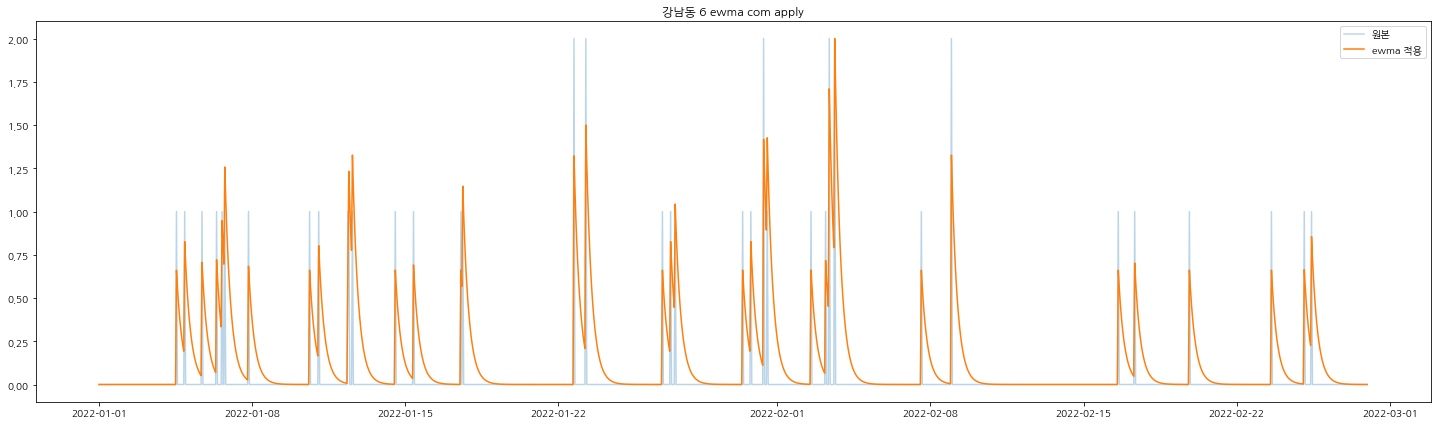

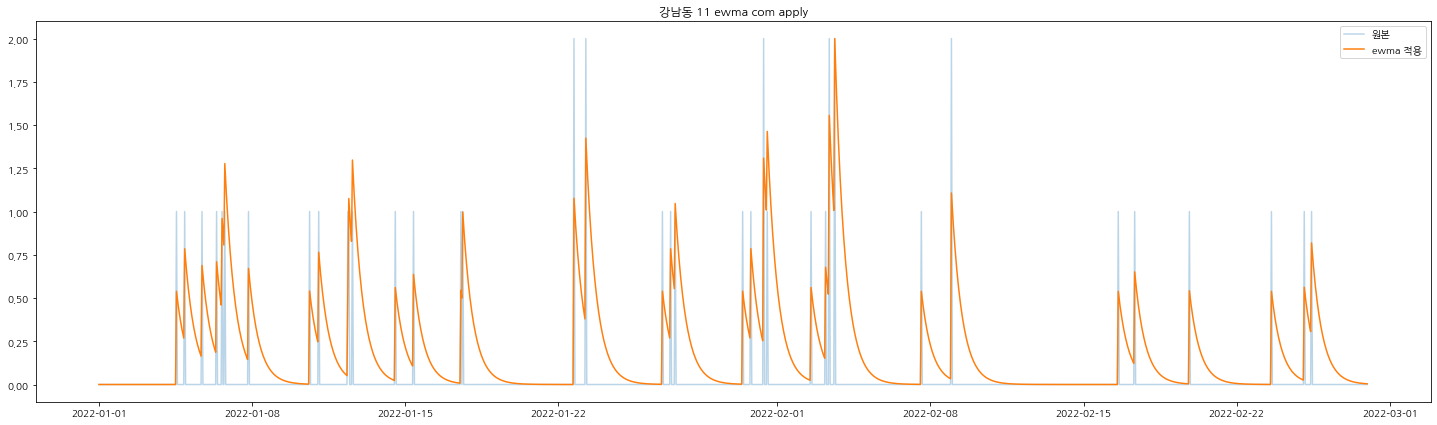

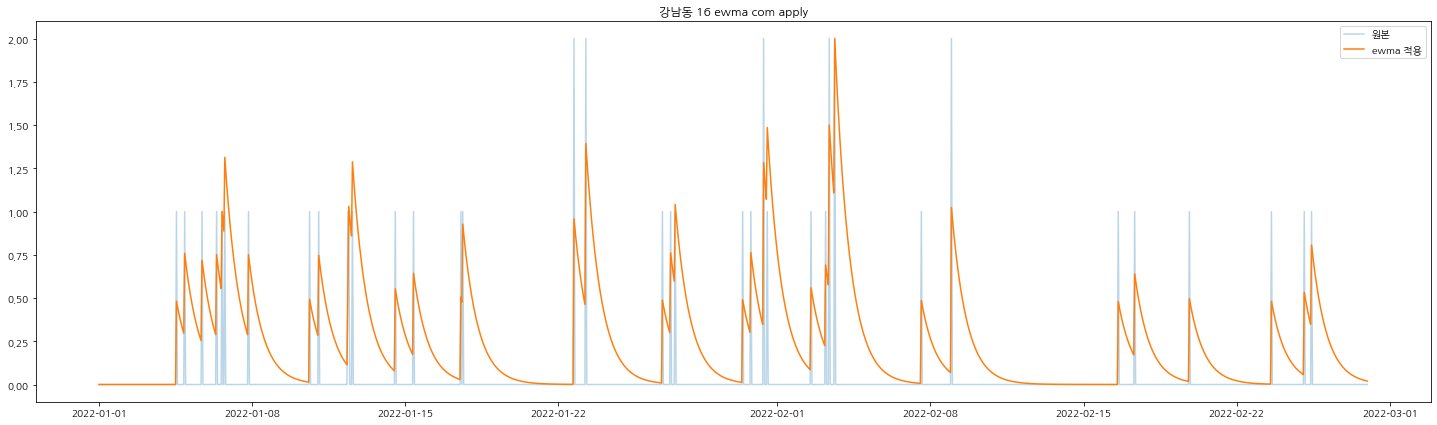

In [7]:
for unit in np.arange(1,20, 5):
    test_data = data_processing('../../test.csv' , unit, moving_average_com)
    target_plot(test_data ,'강남동' , f'강남동 {unit} ewma com apply')

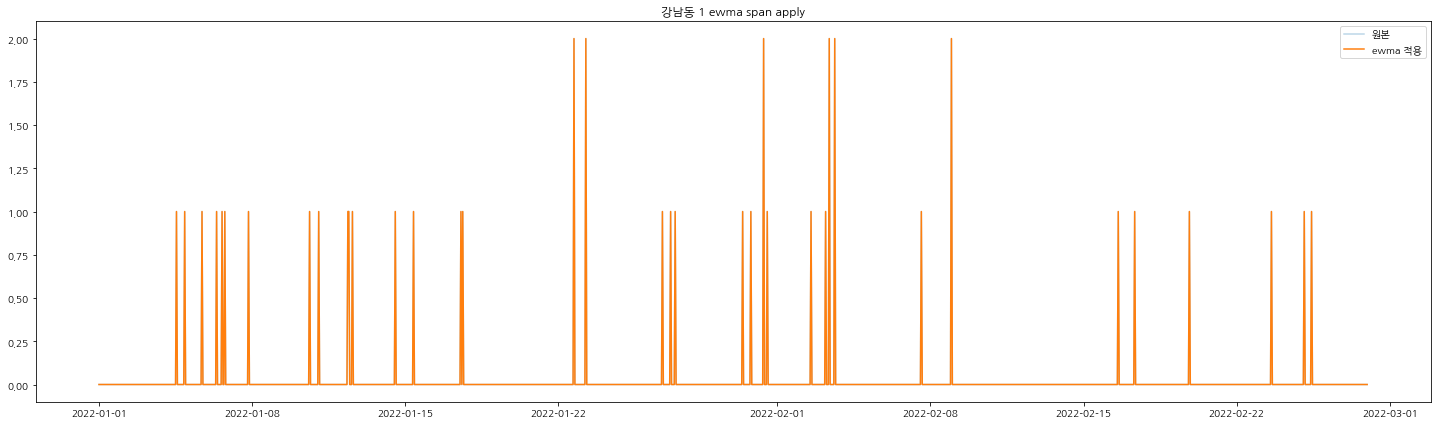

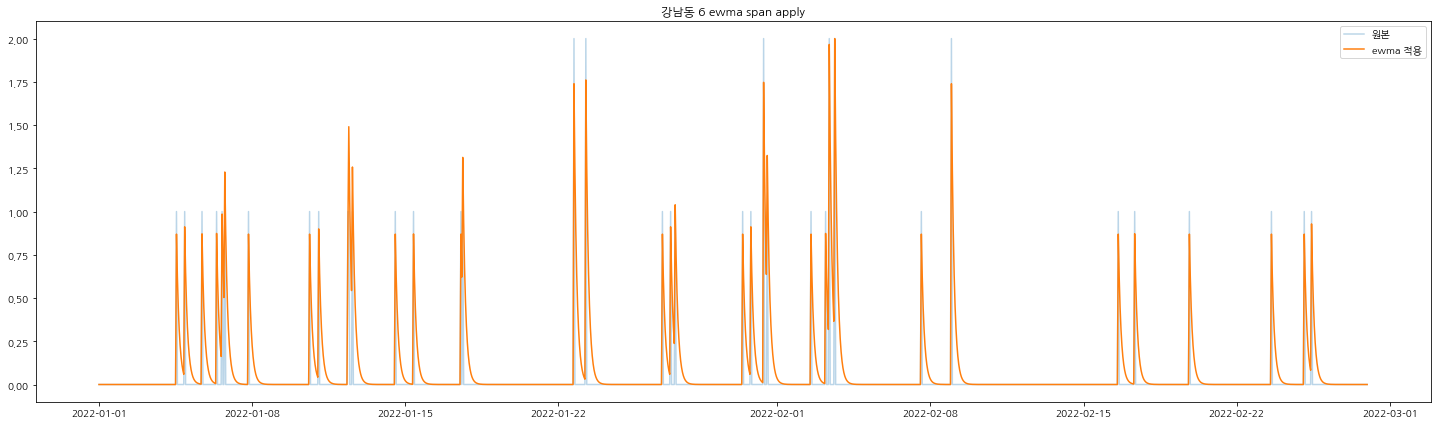

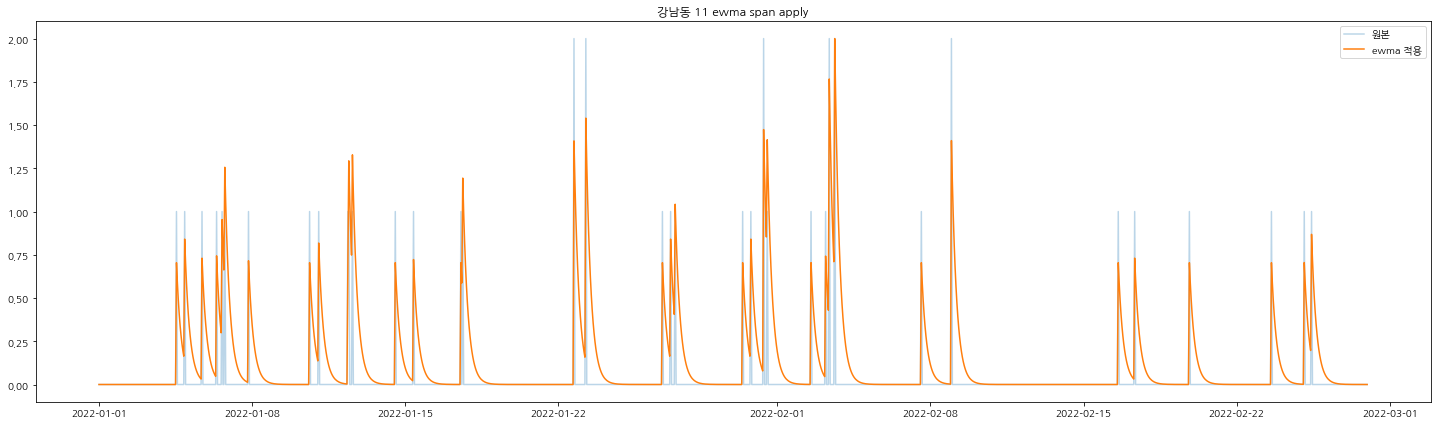

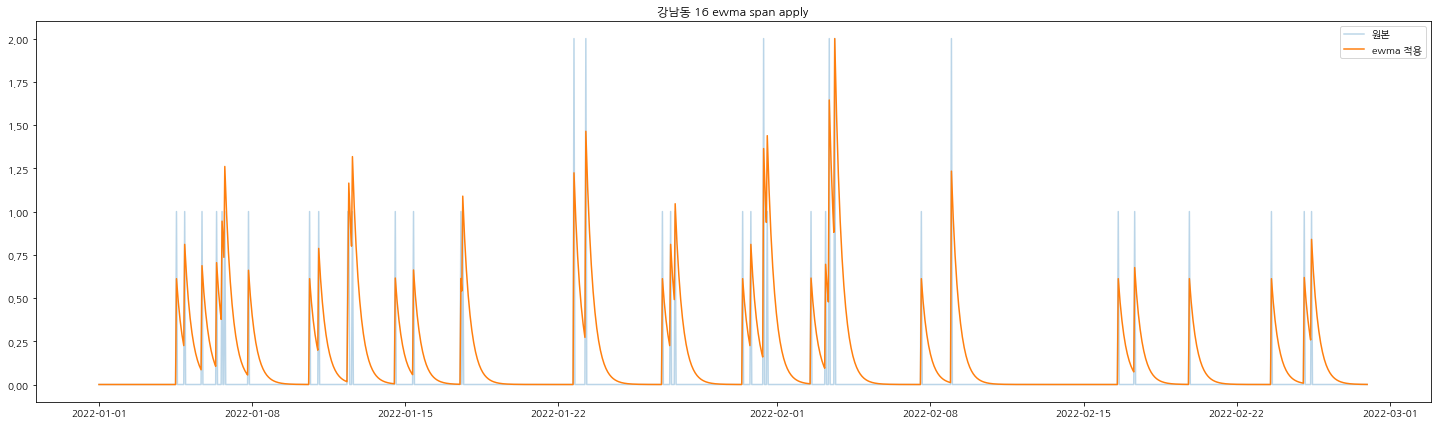

In [8]:
for unit in np.arange(1,20, 5):
    test_data = data_processing('../../test.csv' , unit, moving_average_span)
    target_plot(test_data ,'강남동' , f'강남동 {unit} ewma span apply')

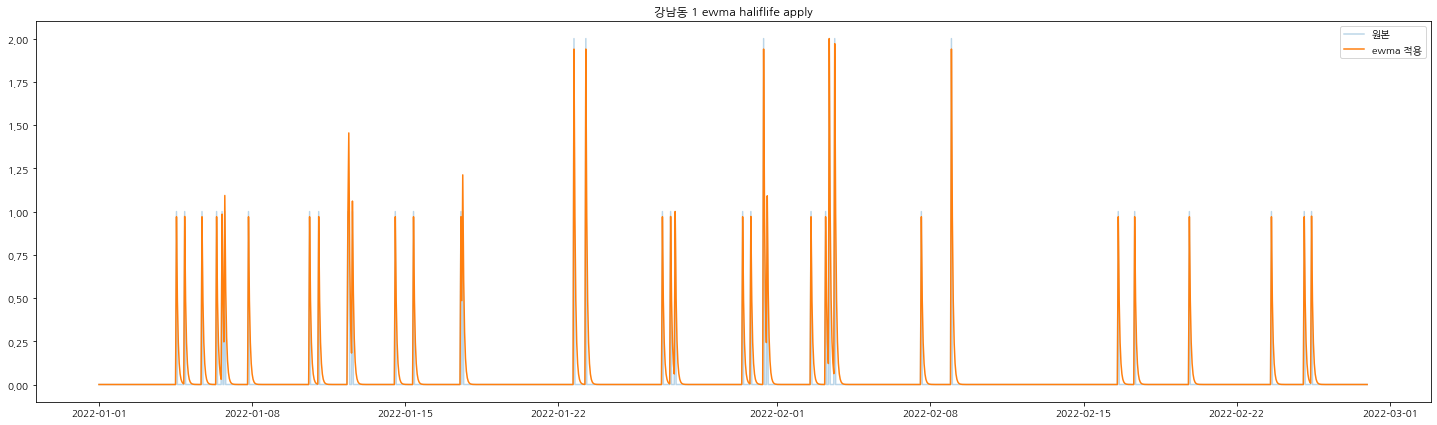

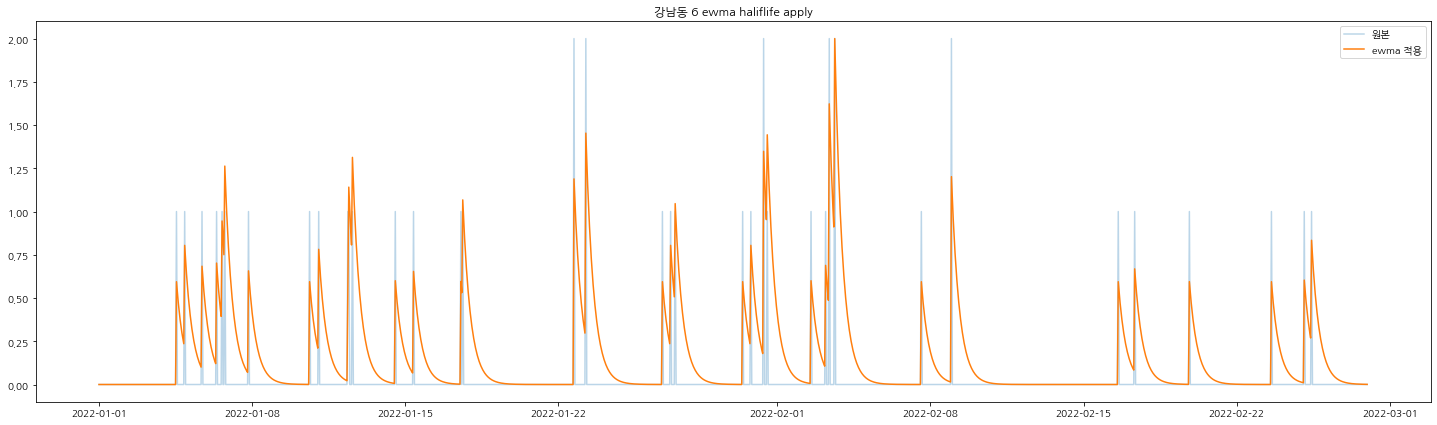

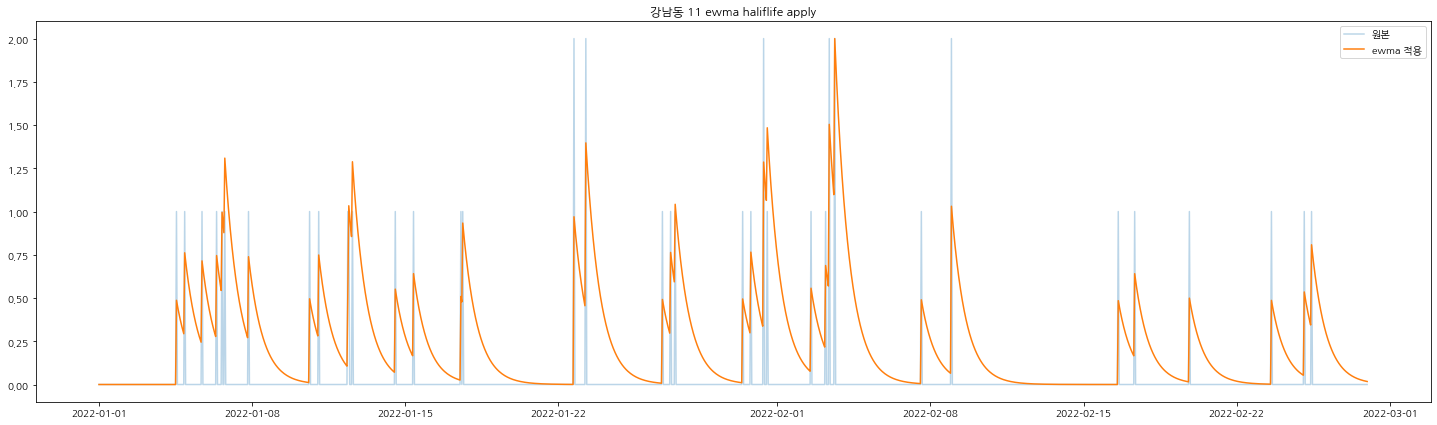

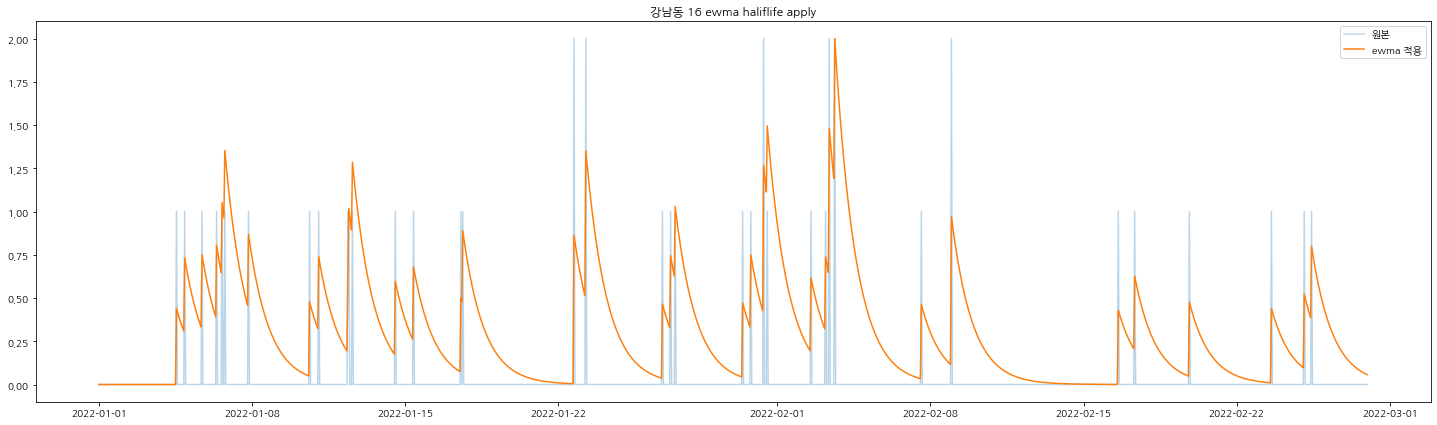

In [9]:
for unit in np.arange(1,20, 5):
    test_data = data_processing('../../test.csv' , unit, moving_average_halflife)
    target_plot(test_data ,'강남동' , f'강남동 {unit} ewma haliflife apply')

# 동별 ewma 비교

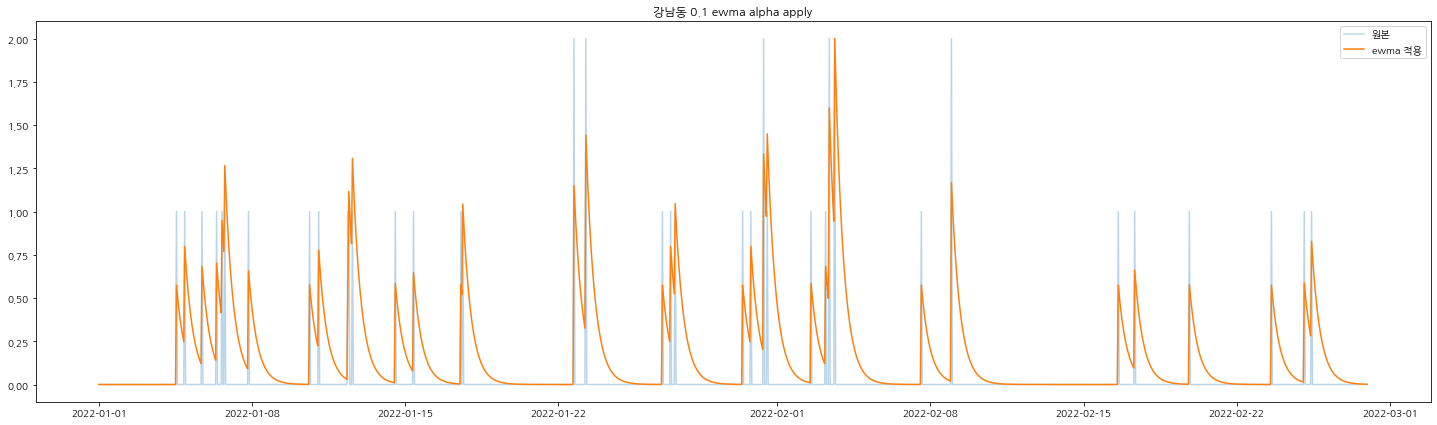

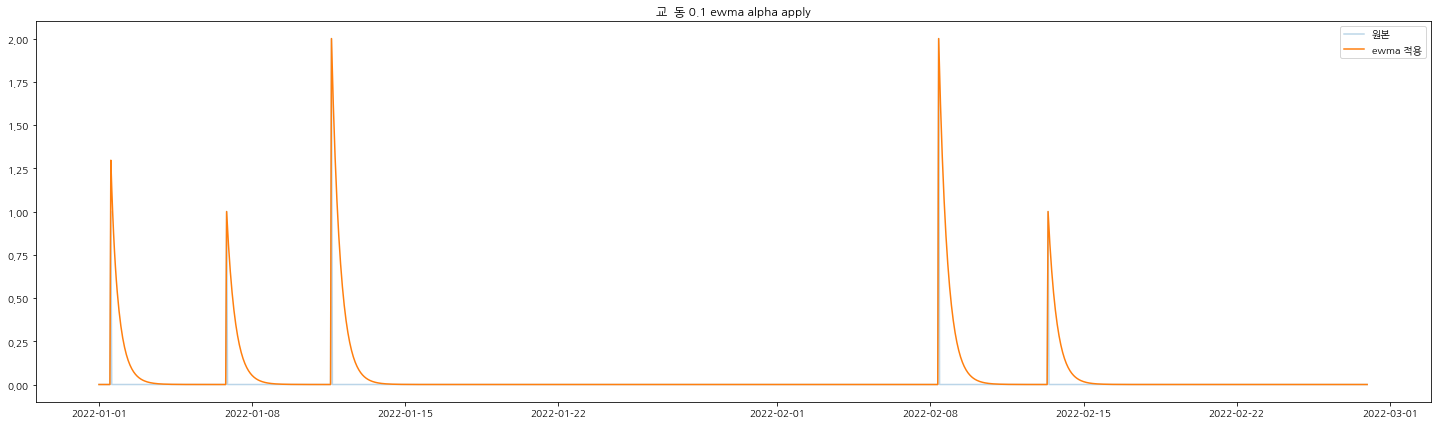

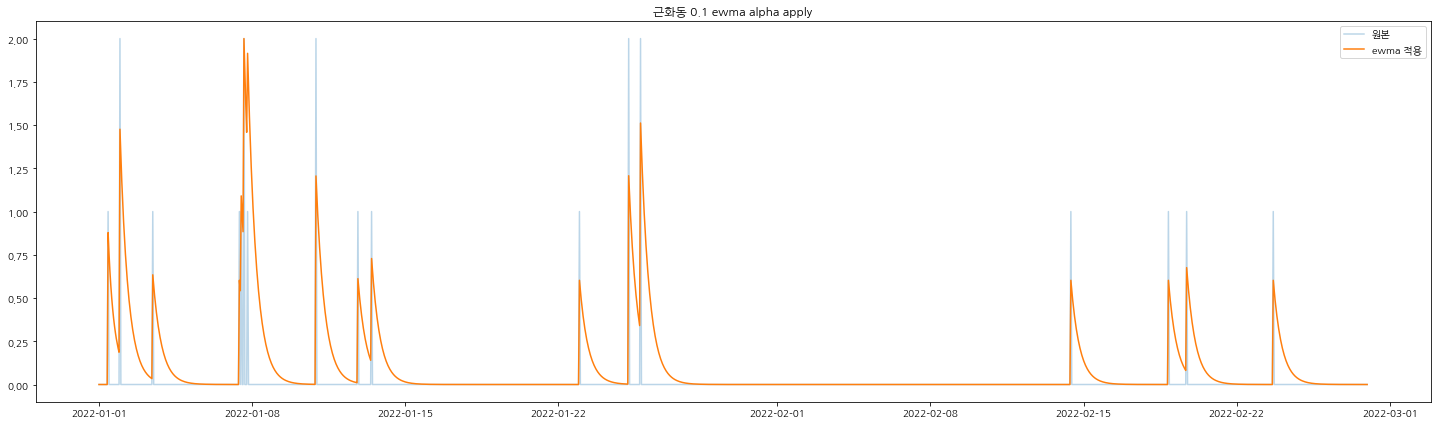

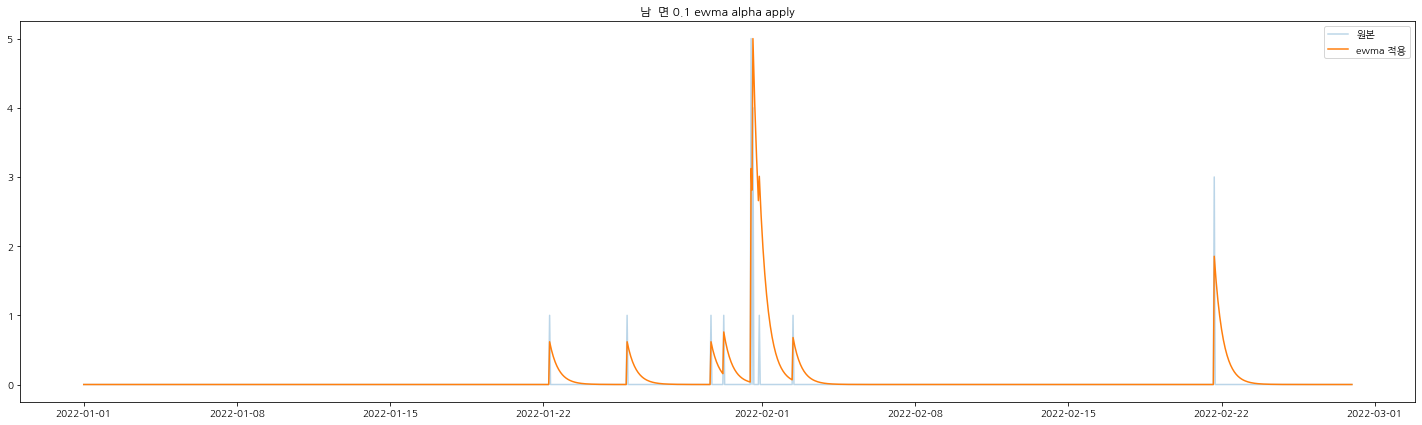

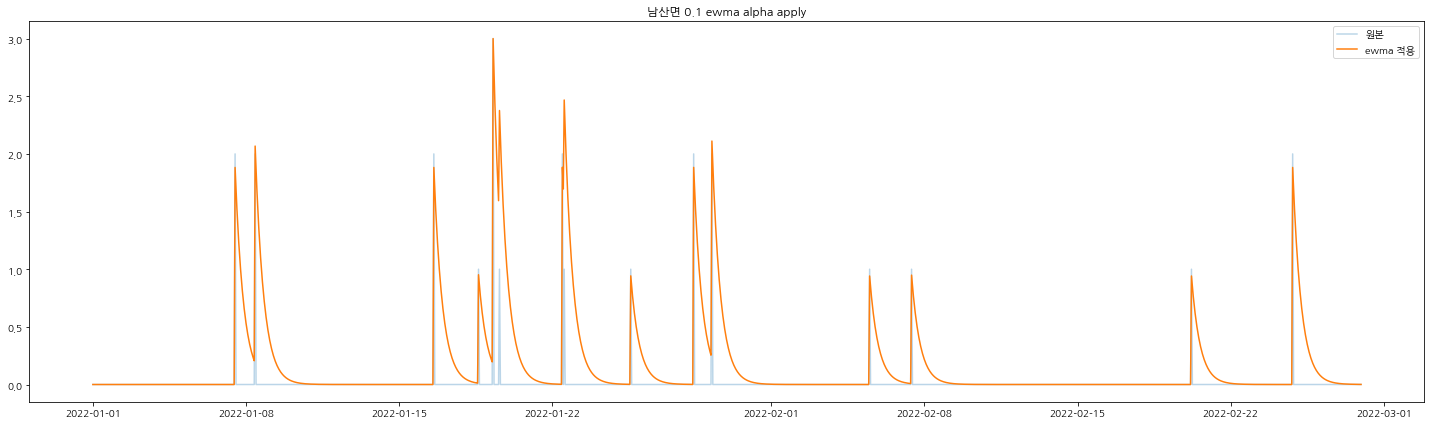

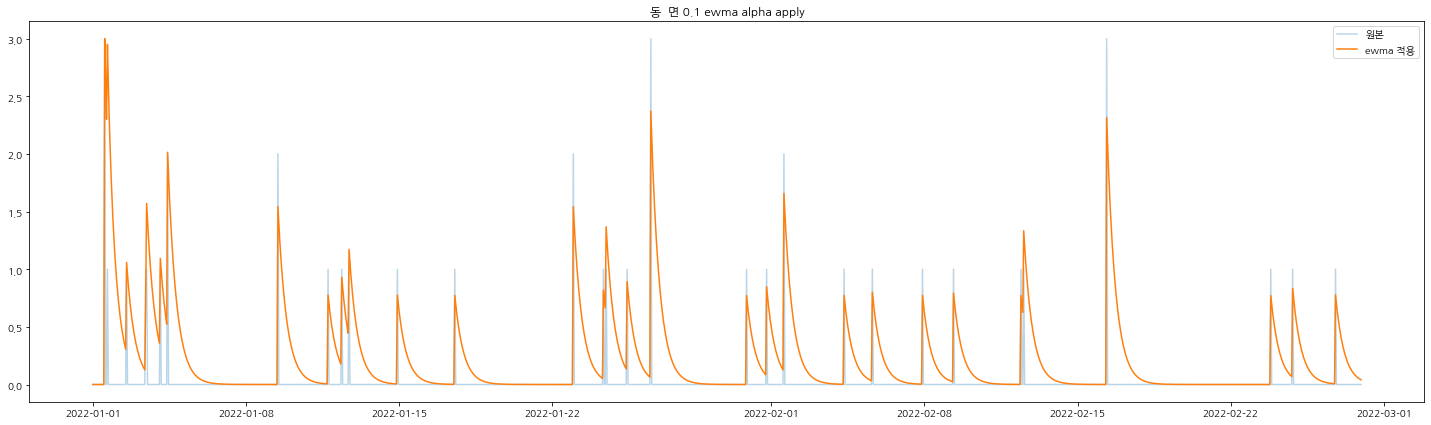

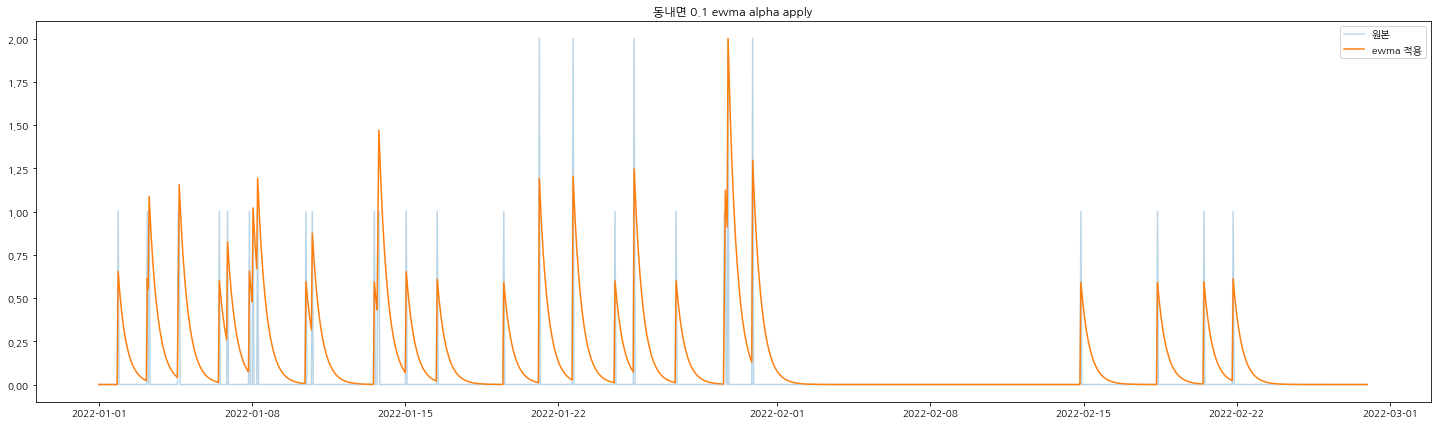

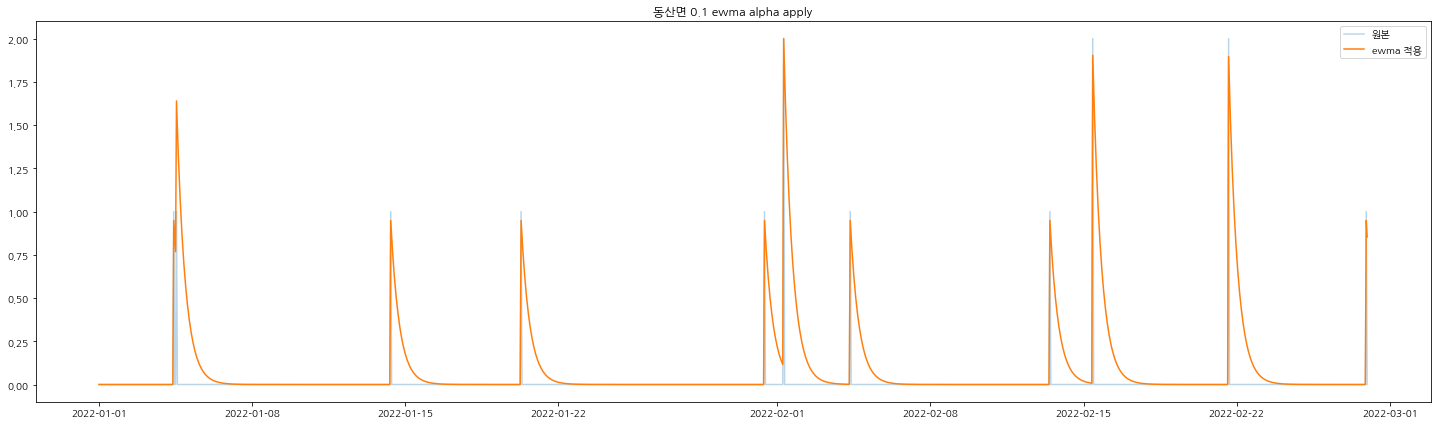

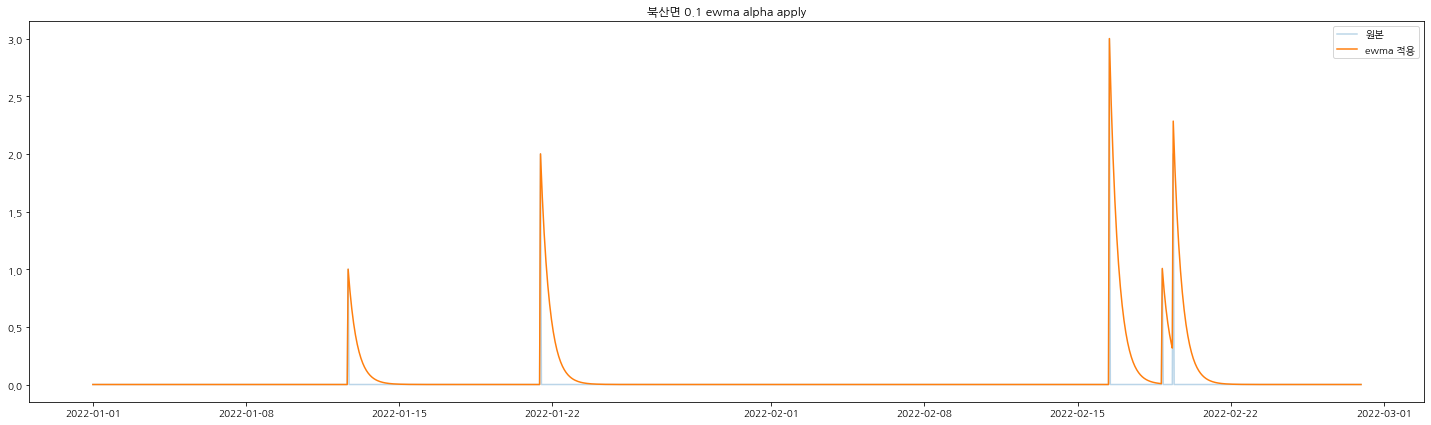

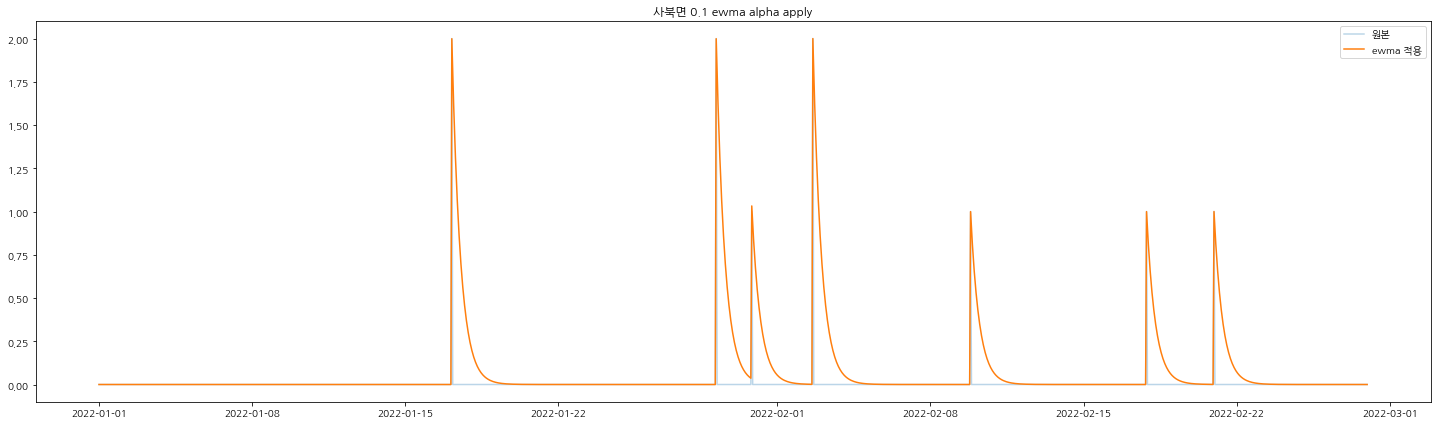

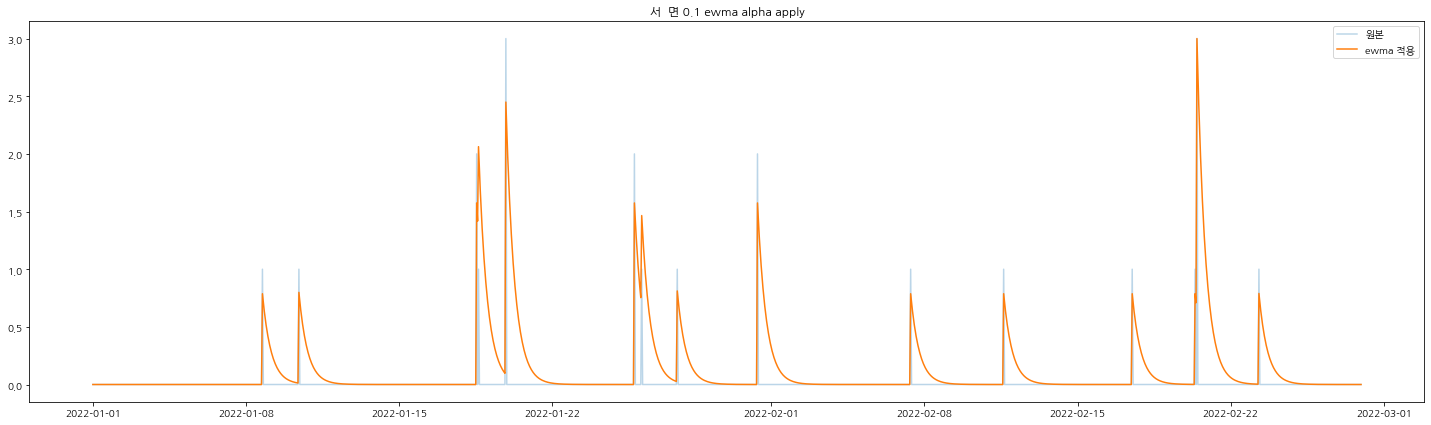

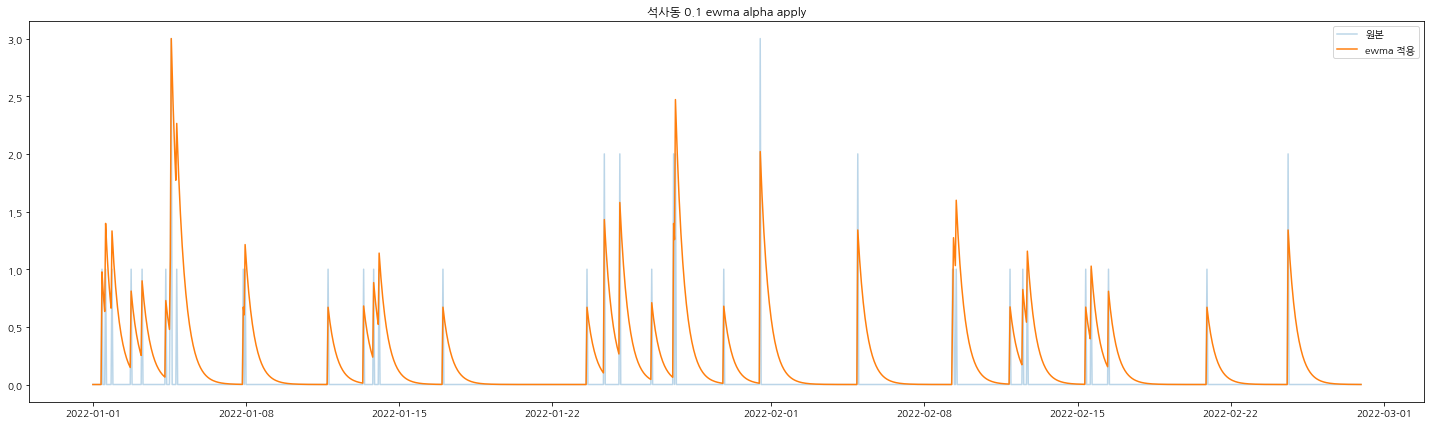

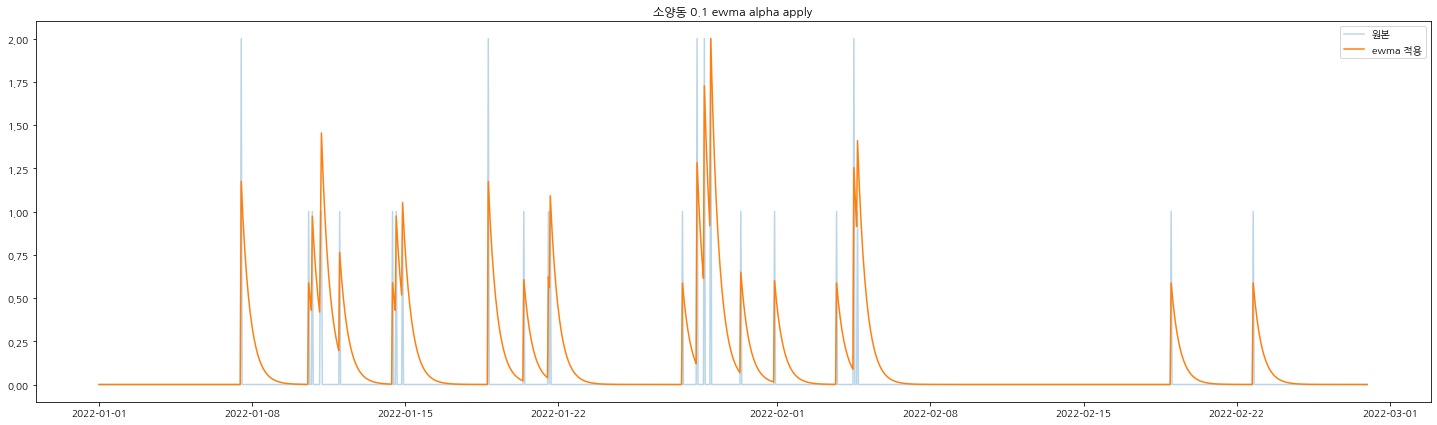

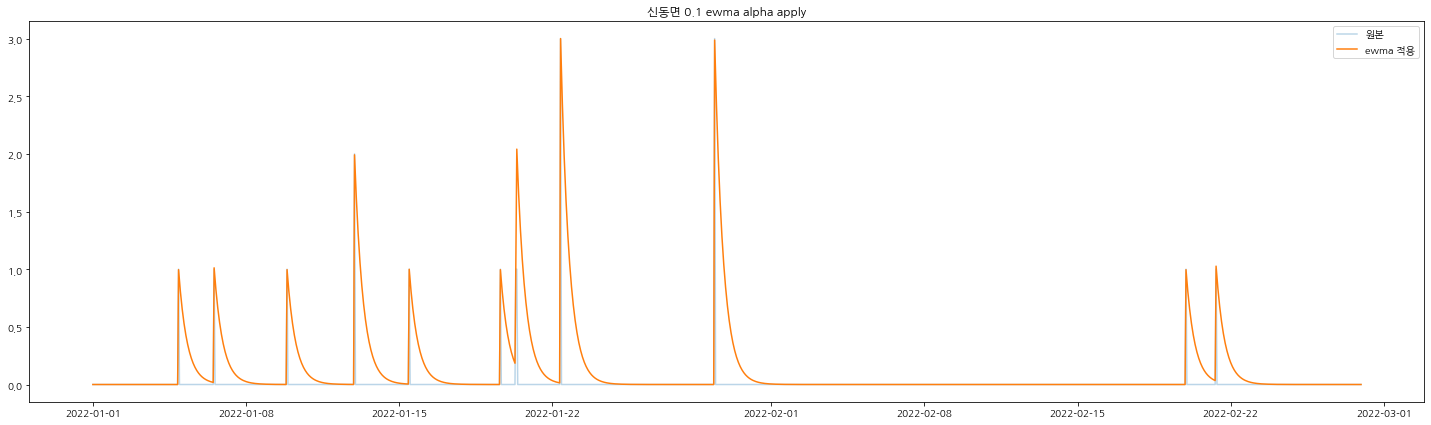

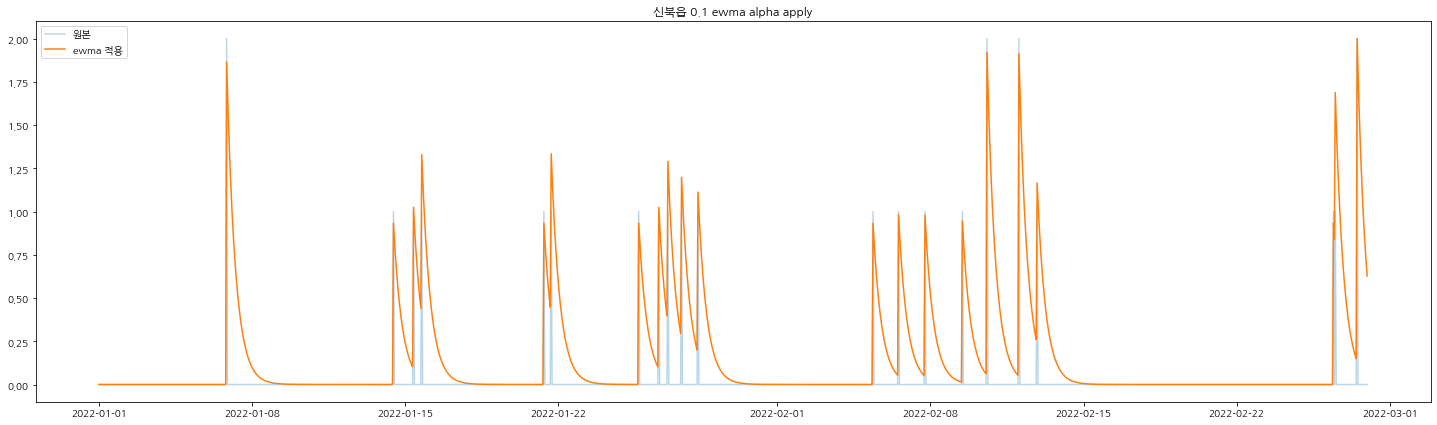

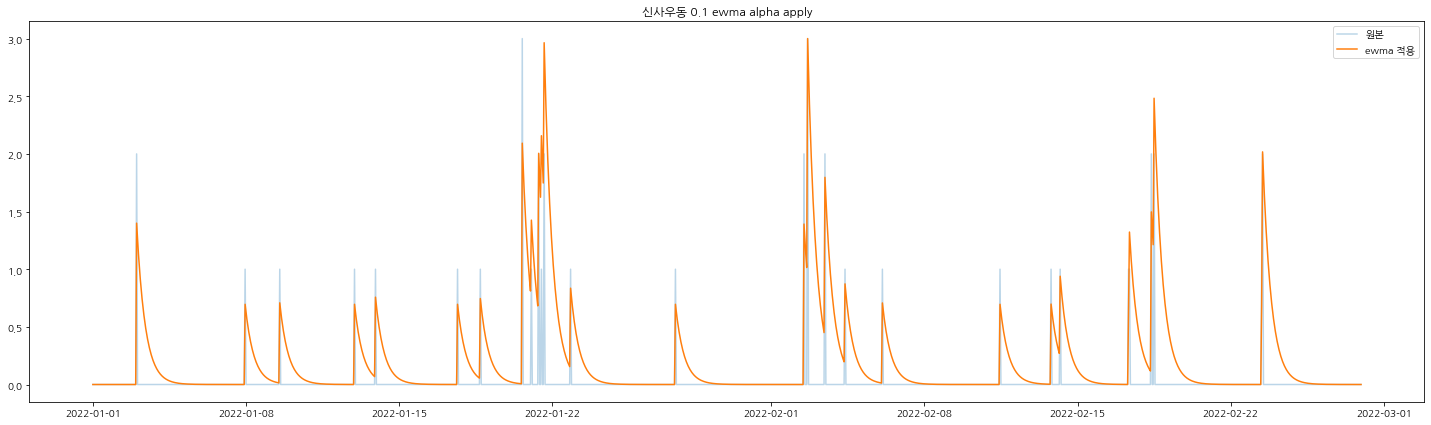

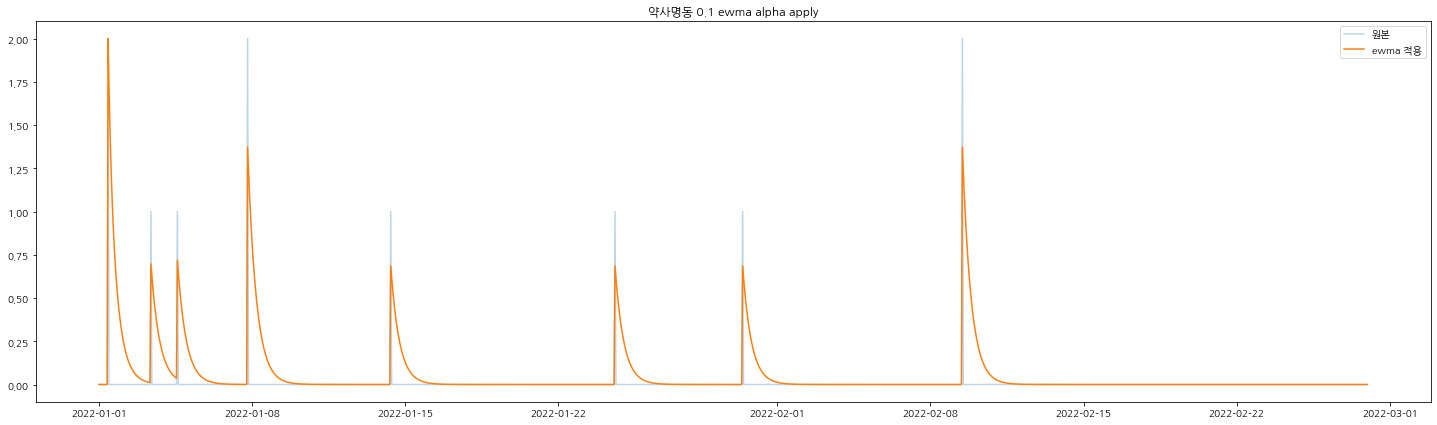

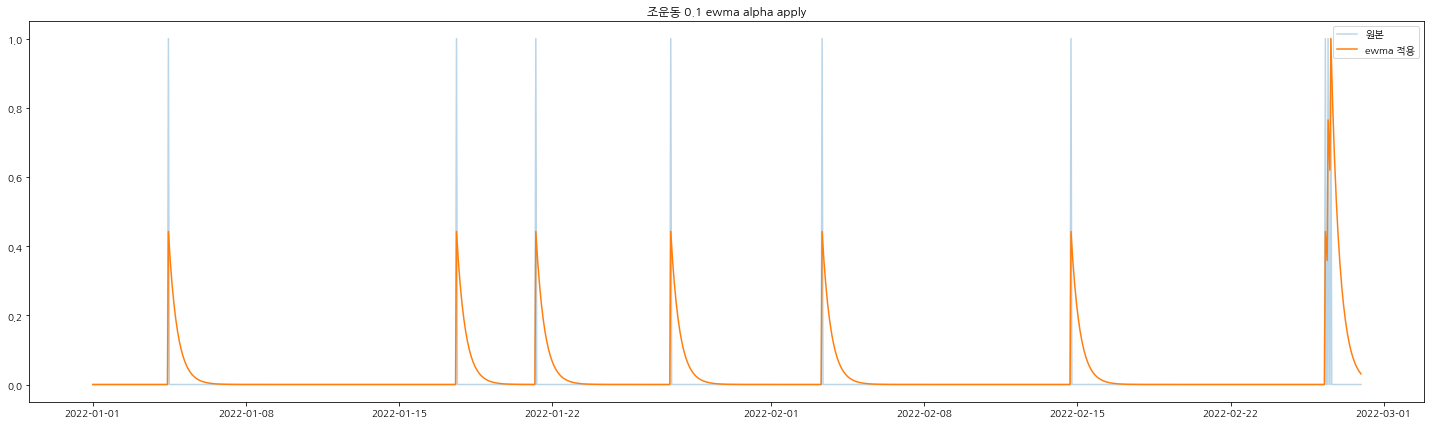

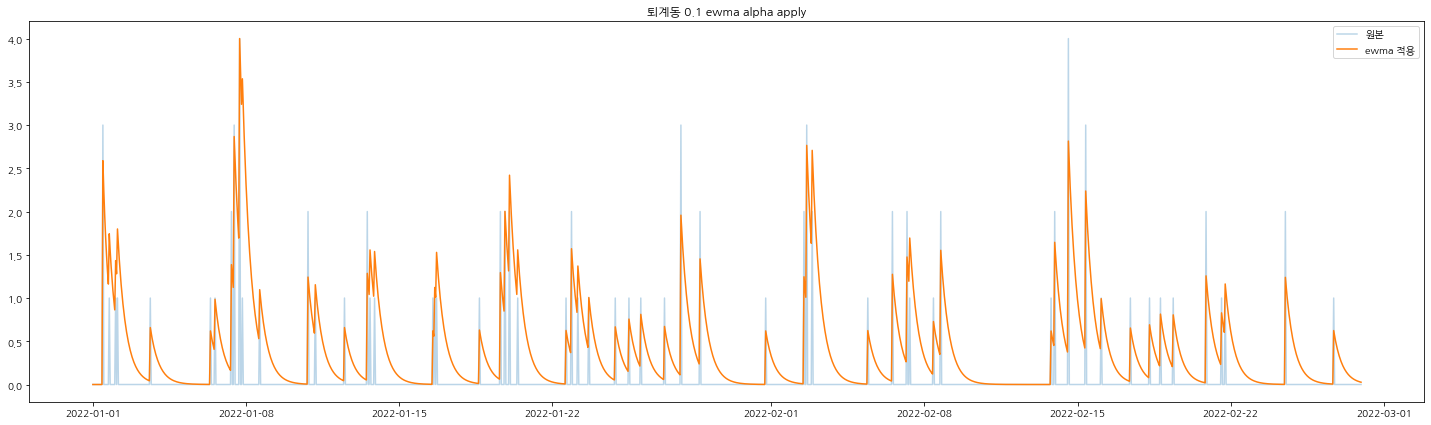

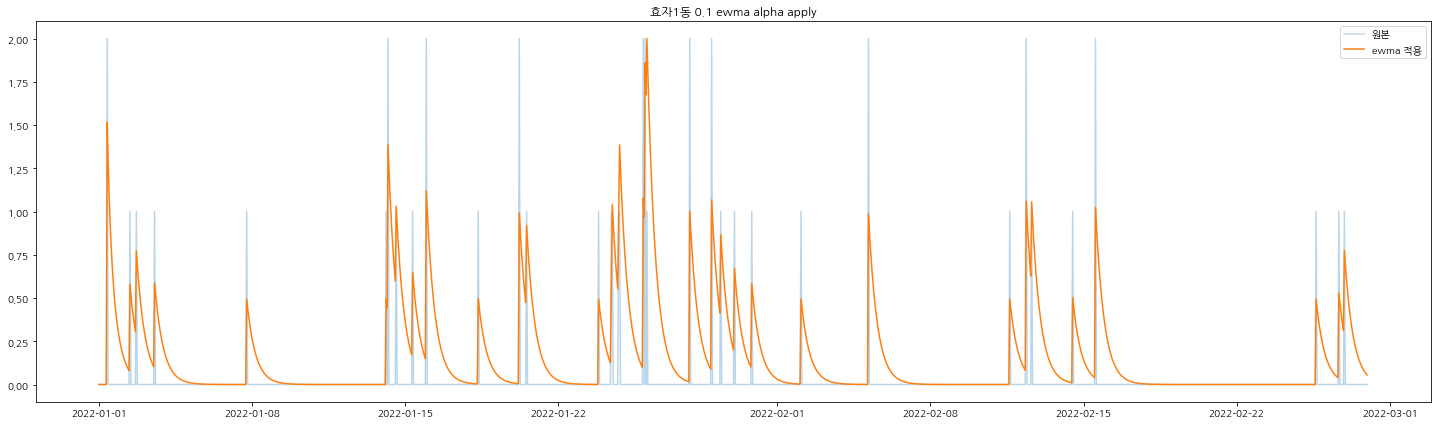

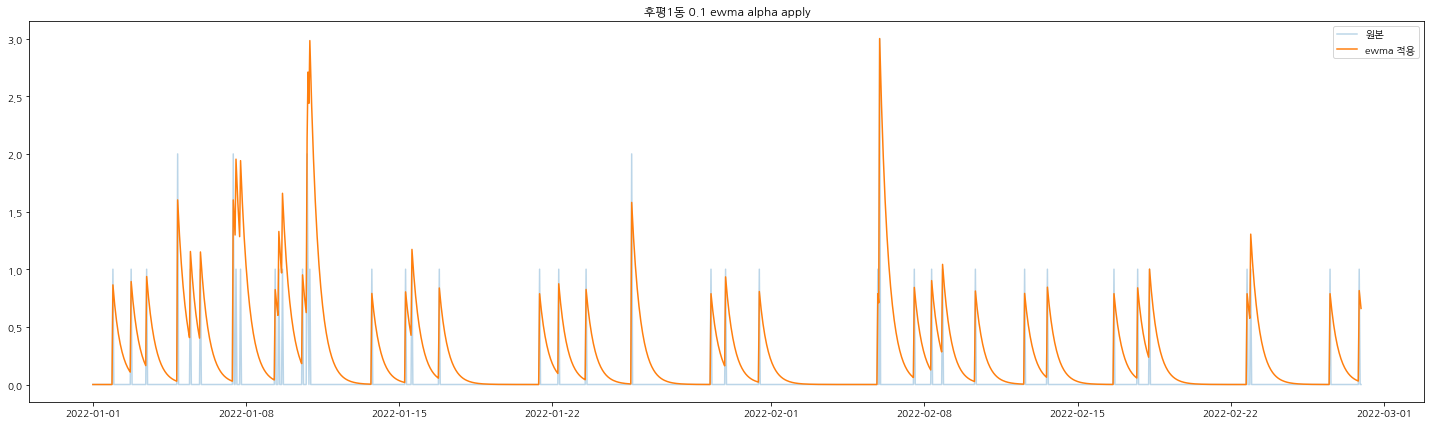

In [10]:
test_data = data_processing('../../test.csv' , 0.1, moving_average_alpha)
for dong in dongs:
    target_plot(test_data ,dong , f'{dong} {0.1} ewma alpha apply')

###### 